# Sigmoid/SGD baseline
Cai Haochen | 58561440

Fresh 54,000/6,000 stratified split; training-only normalization and validation checkpoint selection.

In [1]:
"""Fresh sigmoid/SGD reference run for EE5438 Assignment 1."""
import copy, json, random, time
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torchvision.datasets import FashionMNIST
from sklearn.model_selection import train_test_split

SEED=58561440
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT=Path('results'); OUT.mkdir(exist_ok=True)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type=='cuda': torch.cuda.manual_seed_all(SEED)
raw=FashionMNIST('data',train=True,download=True)
train_idx,val_idx=train_test_split(np.arange(len(raw)),test_size=6000,stratify=raw.targets.numpy(),random_state=SEED)
assert len(set(train_idx)&set(val_idx))==0
assert np.array_equal(np.bincount(raw.targets[val_idx].numpy()),np.full(10,600))
np.savez_compressed(OUT/'split_indices.npz',train=train_idx,validation=val_idx)
x=raw.data.unsqueeze(1).float().div(255)
mean=x[train_idx].mean(); std=x[train_idx].std()
x_train=((x[train_idx]-mean)/std).to(DEVICE).flatten(1); y_train=raw.targets[train_idx].to(DEVICE)
x_val=((x[val_idx]-mean)/std).to(DEVICE).flatten(1); y_val=raw.targets[val_idx].to(DEVICE)
class Baseline(nn.Module):
    def __init__(self):
        super().__init__(); self.net=nn.Sequential(nn.Linear(784,128),nn.Sigmoid(),nn.Linear(128,64),nn.Sigmoid(),nn.Linear(64,10))
    def forward(self,x): return self.net(x)
model=Baseline().to(DEVICE); optimizer=torch.optim.SGD(model.parameters(),lr=1e-3); best=(-1,None,0); history=[]; start=time.perf_counter()
for epoch in range(1,51):
    model.train(); order=torch.randperm(len(x_train),device=DEVICE); seen=correct=0; loss_sum=0.
    for ids in order.split(128):
        optimizer.zero_grad(set_to_none=True); logits=model(x_train[ids]); loss=nn.functional.cross_entropy(logits,y_train[ids]); loss.backward(); optimizer.step()
        loss_sum+=loss.item()*len(ids); correct+=(logits.argmax(1)==y_train[ids]).sum().item(); seen+=len(ids)
    model.eval()
    with torch.no_grad():
        val_logits=torch.cat([model(batch) for batch in x_val.split(512)])
        val_loss=nn.functional.cross_entropy(val_logits,y_val).item(); val_acc=(val_logits.argmax(1)==y_val).float().mean().item()
    row={'epoch':epoch,'train_loss':loss_sum/seen,'train_accuracy':correct/seen,'val_loss':val_loss,'val_accuracy':val_acc,'seconds':time.perf_counter()-start}; history.append(row)
    if (val_acc,-val_loss)>(best[0],best[1] or -float('inf')): best=(val_acc,-val_loss,epoch); torch.save({'state_dict':copy.deepcopy(model.state_dict()),'seed':SEED,'mean':mean.item(),'std':std.item()},OUT/'baseline_sgd_sigmoid.pt')
    if epoch==1 or epoch%10==0: print(row,flush=True)
result={'name':'baseline_sgd_sigmoid','seed':SEED,'device':str(DEVICE),'completed_at':datetime.now(timezone.utc).isoformat(),'train_examples':len(train_idx),'validation_examples':len(val_idx),'best_epoch':best[2],'val_accuracy':best[0],'val_loss':-best[1],'history':history}
(OUT/'baseline_sgd_sigmoid.json').write_text(json.dumps(result,indent=2)); print(json.dumps({k:v for k,v in result.items() if k!='history'},indent=2))


{'epoch': 1, 'train_loss': 2.3135918933727124, 'train_accuracy': 0.1, 'val_loss': 2.3033876419067383, 'val_accuracy': 0.1003333330154419, 'seconds': 0.2376820147037506}


{'epoch': 10, 'train_loss': 2.2574925023538097, 'train_accuracy': 0.4933888888888889, 'val_loss': 2.2544519901275635, 'val_accuracy': 0.49283331632614136, 'seconds': 1.1901045199483633}


{'epoch': 20, 'train_loss': 2.1643313492669, 'train_accuracy': 0.5268148148148148, 'val_loss': 2.156893014907837, 'val_accuracy': 0.5170000195503235, 'seconds': 2.2375011648982763}


{'epoch': 30, 'train_loss': 1.9509596600709138, 'train_accuracy': 0.5029074074074074, 'val_loss': 1.9370026588439941, 'val_accuracy': 0.5049999952316284, 'seconds': 3.2920977845788}


{'epoch': 40, 'train_loss': 1.6913141622543335, 'train_accuracy': 0.5151851851851852, 'val_loss': 1.6789429187774658, 'val_accuracy': 0.5220000147819519, 'seconds': 4.284236563369632}


{'epoch': 50, 'train_loss': 1.4989844250855622, 'train_accuracy': 0.5468888888888889, 'val_loss': 1.4894697666168213, 'val_accuracy': 0.5521666407585144, 'seconds': 5.285016035661101}


{
  "name": "baseline_sgd_sigmoid",
  "seed": 58561440,
  "device": "cuda",
  "completed_at": "2026-09-18T07:59:08.159978+00:00",
  "train_examples": 54000,
  "validation_examples": 6000,
  "best_epoch": 50,
  "val_accuracy": 0.5521666407585144,
  "val_loss": 1.4894697666168213
}


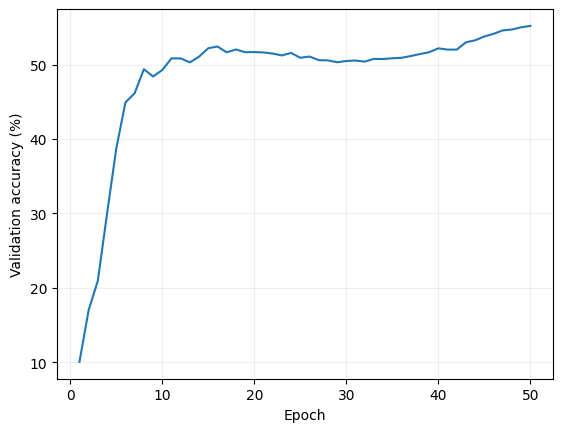

In [2]:
import matplotlib.pyplot as plt
plt.plot([r['epoch'] for r in history],[100*r['val_accuracy'] for r in history])
plt.xlabel('Epoch'); plt.ylabel('Validation accuracy (%)'); plt.grid(alpha=.2); plt.show()